#ML FINAL EXAM

### Email: eva299299@gmail.com

Task: Copy this notebook on your drive and answer in that copy

Choose a dataset of your choice from kaggle or UCI

Some suggestions:https://www.kaggle.com/datasets/ahmettezcantekin/beginner-datasets

You may choose a dataset of your choice too

In this exam:
1. Provide code and explaination(in text cell) whenever needed and you must show the outputs
2. Before submitting run all cells and make sure the outputs are visible


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## 0. Dataset overview
### why this dataset 🇰

#### The Telco Customer Churn dataset contains information about customers of a telecommunications company and whether they left (churned) the company's services. The goal is to analyze customer behavior and build machine learning models to predict whether a customer is likely to churn.

It is a bianry classification problem and it has categorical + quantitative mix, meaningful correlations, a clean classification targe

  

## Answer:



# 1. Dataset description (15 marks)


### Dataset Description
1. How many features?
2. Classification or regression problem? Why do you think so?
3. How many data points?
4. Is there any null values?
5. What kind of features are in your dataset? (Quantitative / Categorical)
6. Do you need to encode the categorical variables, why or why not?
7. Correlation of all the features, What do you understand after the correlation test?
8. Perform exploratory data analysis to extract some important relationships from your data.


Provide necessary codes and explanation

##Answer:

1 . 21

2. binary classification

3. 7043

4. Yes

5. Both

6. Yes , convert to numerical

7. Higher churn is associated with month-to-month contracts, higher monthly charges, and shorter customer tenure.

8.  Specified Below


#2. Dataset pre-processing (15 marks)

1. Provide code
2. Discuss the pre processing steps you applied and why?


In [52]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

from sklearn.linear_model import SGDRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

from sklearn.metrics import mean_squared_error,r2_score,root_mean_squared_error,mean_absolute_error

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score,precision_score,recall_score

from sklearn.metrics import confusion_matrix,classification_report

from sklearn.model_selection import GridSearchCV

## Answer: pre processing steps :

## 1.Handing missing values

   ## 2 . Encoding and Scaling

   ## 3. Dropping unnessary feature (customer_id)


   

In [5]:
df = pd.read_csv('/content/sample_data/Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [23]:
### Handing missing TotalCharge

print((df["TotalCharges"] == " ").sum())  # missing values

df['TotalCharges'] =df['TotalCharges'].replace(" ",np.nan)

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])
df["TotalCharges"].fillna(df['TotalCharges'].mean() , inplace = True )
df.info()

0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object

/tmp/ipykernel_1413/4212588316.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df['TotalCharges'].mean() , inplace = True )


<Axes: >

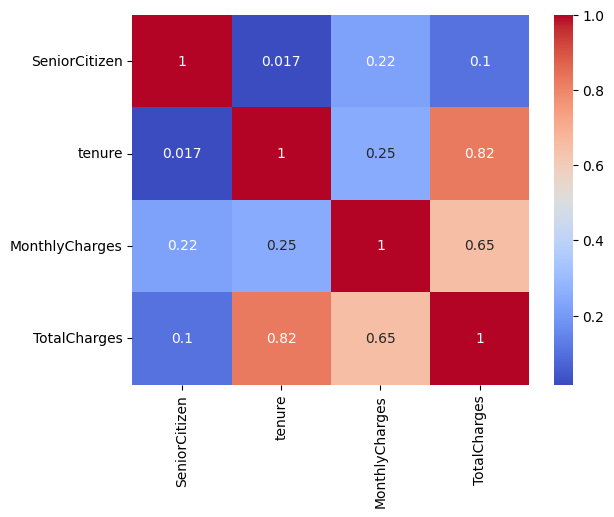

In [26]:
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')


In [27]:


df.drop("customerID" , axis =1 , inplace = True )  # droping unnecessayr feature



In [33]:
### Encoding  and Scaling   pipeline

numerical_cols = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

ordinal_cols = ["Contract"] # may have influence Month-to-month < One year < Two year)

nominal_cols = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "PaperlessBilling",
    "PaymentMethod"
]

preprocessor = ColumnTransformer(
    transformers  = [
        ('num' , StandardScaler() , numerical_cols) ,
        ('ord' , OrdinalEncoder(categories=[[
             "Month-to-month", "One year","Two year"]]),  ordinal_cols),
        ("nom" , OneHotEncoder(handle_unknown="ignore") , nominal_cols)
    ]
)

preprocessor


ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['SeniorCitizen', 'tenure', 'MonthlyCharges',
                                  'TotalCharges']),
                                ('ord',
                                 OrdinalEncoder(categories=[['Month-to-month',
                                                             'One year',
                                                             'Two year']]),
                                 ['Contract']),
                                ('nom', OneHotEncoder(handle_unknown='ignore'),
                                 ['gender', 'Partner', 'Dependents',
                                  'PhoneService', 'MultipleLines',
                                  'InternetService', 'OnlineSecurity',
                                  'OnlineBackup', 'DeviceProtection',
                                  'TechSupport', 'StreamingTV',
                                  'StreamingMovies', 'PaperlessBilling',
                                  'PaymentMethod'])])

In [38]:
# Features (inputs)
X = df.drop("Churn", axis=1)

# Target (output)
y = df["Churn"].map({"No": 0, "Yes": 1})



#3.Feature selection and Dataset splitting (10 marks)

1. Which features you wanna keep ? Justify and drop and rest or apply any other feature engineering step
2. Perform Train test split

## Answer:  Dropped (previous step)  CUstomerID because it has no meaning in training and keeping the rest of features




In [39]:
# train -test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


X_temp = preprocessor.fit_transform(X_train) # appling column trnasfer on train data

print(preprocessor.get_feature_names_out())
print(X_temp.shape)

['num__SeniorCitizen' 'num__tenure' 'num__MonthlyCharges'
 'num__TotalCharges' 'ord__Contract' 'nom__gender_Female'
 'nom__gender_Male' 'nom__Partner_No' 'nom__Partner_Yes'
 'nom__Dependents_No' 'nom__Dependents_Yes' 'nom__PhoneService_No'
 'nom__PhoneService_Yes' 'nom__MultipleLines_No'
 'nom__MultipleLines_No phone service' 'nom__MultipleLines_Yes'
 'nom__InternetService_DSL' 'nom__InternetService_Fiber optic'
 'nom__InternetService_No' 'nom__OnlineSecurity_No'
 'nom__OnlineSecurity_No internet service' 'nom__OnlineSecurity_Yes'
 'nom__OnlineBackup_No' 'nom__OnlineBackup_No internet service'
 'nom__OnlineBackup_Yes' 'nom__DeviceProtection_No'
 'nom__DeviceProtection_No internet service' 'nom__DeviceProtection_Yes'
 'nom__TechSupport_No' 'nom__TechSupport_No internet service'
 'nom__TechSupport_Yes' 'nom__StreamingTV_No'
 'nom__StreamingTV_No internet service' 'nom__StreamingTV_Yes'
 'nom__StreamingMovies_No' 'nom__StreamingMovies_No internet service'
 'nom__StreamingMovies_Yes' 'nom_

#4.  Pipeline Creation (Supervised) (10 marks)

Select 2 models of your choice and build 2 pipelines for them

## Answer:  1. Linear regression
### 2. SDE Regression

In [50]:
# Linear Regression
linear_pipeline = Pipeline( steps=[
    ('preprocessor' , preprocessor) ,
    ('model' , LinearRegression())
])

linear_pipeline


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('ord',
                                                  OrdinalEncoder(categories=[['Month-to-month',
                                                                              'One '
                                                                              'year',
                                                                              'Two '
                                                                              'year']]),
                                                  ['Contract']),
                                                 ('nom',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('model', LinearRegression())])

In [54]:
# rrandom Forest

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

rf_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('ord',
                                                  OrdinalEncoder(categories=[['Month-to-month',
                                                                              'One '
                                                                              'year',
                                                                              'Two '
                                                                              'year']]),
                                                  ['Contract']),
                                                 ('nom',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('model', RandomForestClassifier(random_state=42))])

In [55]:
# Random Forest


# Define the parameter grid for GridSearchCV, now referencing the model in the pipeline
grid_param_rf = {
    'model__n_estimators' : [100, 150, 200, 300], # how many trees should be built
    'model__criterion' : ['gini', 'entropy']  # best spliting feature
   # 'model__max_depth' : range(2,10,1) ,
   # 'model__min_samples_leaf' : range(1,10,1) ,
   # 'model__min_samples_split' : range(2,10,1) ,
   # 'model__max_features' :['sqrt' , 'log2']
}

grid_search_RF = GridSearchCV(
    estimator = rf_pipeline, # Use the pipeline as the estimator
    param_grid = grid_param_rf,
    cv = 3,
    n_jobs=-1,
    verbose=2
)



# 5. Model Training (5 marks)

Train those 2 models



## Answer:

In [56]:
linear_pipeline.fit(X_train,y_train)
grid_search_RF.fit(X_train, y_train)


print(grid_search_RF.best_params_)


Fitting 3 folds for each of 8 candidates, totalling 24 fits
{'model__criterion': 'entropy', 'model__n_estimators': 300}


#6. Model selection/Comparison analysis (15 marks)
* Bar chart showcasing prediction accuracy of all models (for classification)
* Precision, recall comparison of each model. (for classification)
* Confusion Matrix (for classification)
* R2 score and Loss  (for regression)

Compare the results of all models based on all of the above described metrics. Why do you think this model performed better than the other one for this dataset?

# Answer:

In [57]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Get predictions for Linear Regression
y_pred_lr_continuous = linear_pipeline.predict(X_test)

# Convert continuous predictions to binary (0 or 1) using a threshold (e.g., 0.5)
y_pred_lr = (y_pred_lr_continuous > 0.5).astype(int)

# Get predictions for Random Forest
y_pred_rf = grid_search_RF.predict(X_test) # Predict on X_test

#  metrics for Linear Regressio
acc_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)

# metrics for Random Forest
acc_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)

print(f"Linear Regression Accuracy: {acc_lr:.4f}")
print(f"Linear Regression Precision: {precision_lr:.4f}")
print(f"Linear Regression Recall: {recall_lr:.4f}")
print("\n")
print(f"Random Forest Accuracy: {acc_rf:.4f}")
print(f"Random Forest Precision: {precision_rf:.4f}")
print(f"Random Forest Recall: {recall_rf:.4f}")

Linear Regression Accuracy: 0.8226
Linear Regression Precision: 0.7113
Linear Regression Recall: 0.5550


Random Forest Accuracy: 0.7970
Random Forest Precision: 0.6617
Random Forest Recall: 0.4772


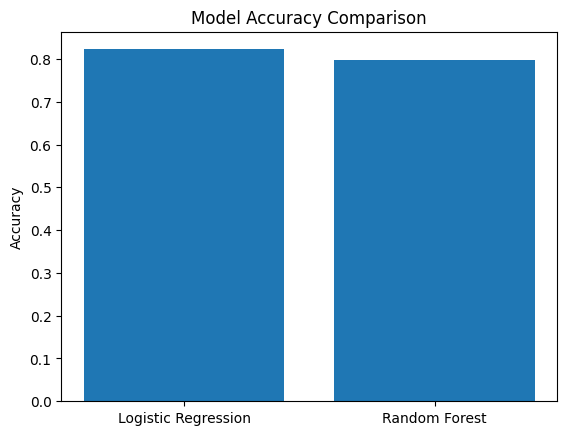

In [59]:
import matplotlib.pyplot as plt

models = ["Logistic Regression", "Random Forest"]
accuracy = [acc_lr, acc_rf]

plt.bar(models, accuracy)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

Confusion Matrix for Random Forest Classifier (Best Estimator)


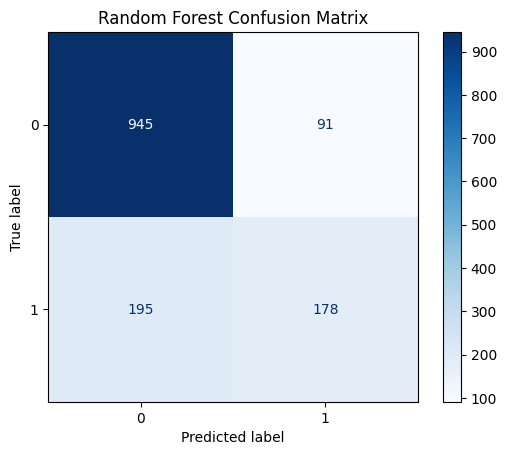

In [63]:
print('Confusion Matrix for Random Forest Classifier (Best Estimator)')
ConfusionMatrixDisplay.from_estimator(grid_search_RF.best_estimator_, X_test, y_test, cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.show()

Confusion Matrix for Linear Regression (as Classifier)


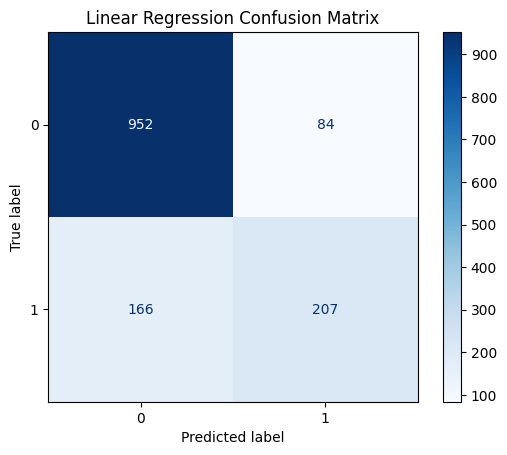

In [62]:
print('Confusion Matrix for Linear Regression (as Classifier)')
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, cmap='Blues')
plt.title('Linear Regression Confusion Matrix')
plt.show()

In [65]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np # Import numpy for square root function

# Calculate R2 Score for Linear Regression using its continuous predictions
r2_lr = r2_score(y_test, y_pred_lr_continuous)

# Calculate RMSE (Root Mean Squared Error) for Linear Regression
mse_lr = mean_squared_error(y_test, y_pred_lr_continuous)
rmse_lr = np.sqrt(mse_lr)

print(f"Linear Regression R2 Score: {r2_lr:.4f}")
print(f"Linear Regression RMSE: {rmse_lr:.4f}")

Linear Regression R2 Score: 0.3060
Linear Regression RMSE: 0.3675


### Random Forest accuracy: 0.7970, Linear Regression accuracy: 0.8226.

#### Linear Regression  performed better because the dataset might have a more linear relationship  .

####  Random Forest,  more complex, could have overfit the training data or found its complexity unnecessary for the inherent patterns in this specific dataset.


# 7. Treating the problem as Unsupervised (20 marks) ( Explore the topic as you wish )

1. Treat the problem as a unsupervised problem and perform any unsupervised model and evalute the result
2. Which method worked better? supervised or unsupervised approach and why?

# Answer:

In [66]:
X_cluster = df[["tenure", "MonthlyCharges", "TotalCharges"]]

In [67]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

In [69]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps = 0.3 , min_samples = 4)


In [71]:
dbscan.fit(X_scaled)

labels= dbscan.labels_

clusters = dbscan.fit_predict(X_scaled)

In [74]:
df["Cluster"] = labels
print("Cluster Counts:")
print(df["Cluster"].value_counts())
print(df[["tenure",
          "MonthlyCharges",
          "TotalCharges",
          "Cluster"]].head(8))



Cluster Counts:
Cluster
 0    7032
 1       6
-1       5
Name: count, dtype: int64
   tenure  MonthlyCharges  TotalCharges  Cluster
0       1           29.85         29.85        0
1      34           56.95       1889.50        0
2       2           53.85        108.15        0
3      45           42.30       1840.75        0
4       2           70.70        151.65        0
5       8           99.65        820.50        0
6      22           89.10       1949.40        0
7      10           29.75        301.90        0


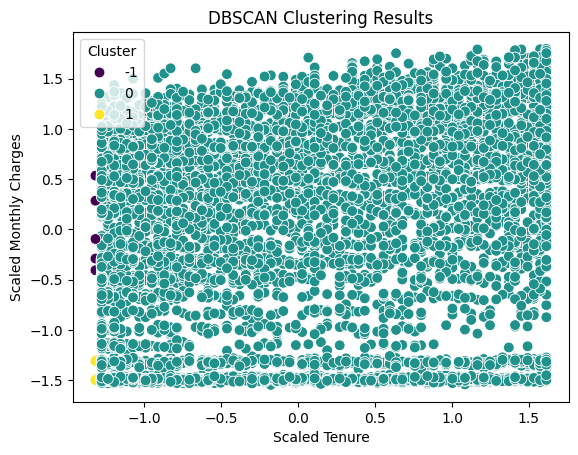

In [76]:
sns.scatterplot(
    x=X_scaled[:,0],
    y=X_scaled[:,1],
    hue=labels,
    palette="viridis",
    s=60
)

plt.title("DBSCAN Clustering Results")
plt.xlabel("Scaled Tenure")
plt.ylabel("Scaled Monthly Charges")
plt.legend(title="Cluster")
plt.show()

#8. Self Reflection on this machine learning course (10 marks)

Explain the hardest and the easiest topic of this course according to you in a intuitive way (you may also provide real world implementation , necessity etc along with the explaination)

##Answer: Easiest Topic = Linear Regreesion , SDG , EDA ,

### Hardest TAsk : Unsupervised Leanring